# Large Dataset Analysis

This notebook first validates `large_dataset/` against `filtered_ids3.json`, then runs all downstream analysis only on matched image + JSON pairs.

In [1]:
from __future__ import annotations

import json
import textwrap
from multiprocessing import cpu_count, get_context
from multiprocessing.pool import ThreadPool
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Rectangle
from PIL import Image

plt.style.use("seaborn-v0_8-whitegrid")

DATASET_DIR = Path("large_dataset")
METADATA_PATH = Path("filtered_ids3.json")
REQUIRED_FIELDS = {"orig_face_crop", "new_face_crop", "body_crop", "orig_image_size", "text"}
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")
RNG_SEED = 42
SAMPLE_SIZE = 10

with METADATA_PATH.open("r", encoding="utf-8") as f:
    METADATA = json.load(f)

FOLDER_NAMES_ON_DISK = sorted(path.name for path in DATASET_DIR.iterdir() if path.is_dir())
FOLDER_NAMES_IN_JSON = sorted(METADATA)
FOLDERS_TO_SCAN = sorted(set(FOLDER_NAMES_ON_DISK) | set(FOLDER_NAMES_IN_JSON))

print(f"Dataset directory: {DATASET_DIR.resolve()}")
print(f"Metadata file: {METADATA_PATH.resolve()}")
print(f"Folders on disk: {len(FOLDER_NAMES_ON_DISK):,}")
print(f"Folders in JSON: {len(FOLDER_NAMES_IN_JSON):,}")


Dataset directory: /home/kolyangg/rsrch/dataset_full/large_dataset
Metadata file: /home/kolyangg/rsrch/dataset_full/filtered_ids3.json
Folders on disk: 3,938
Folders in JSON: 3,866


In [2]:
def natural_sort_key(value: str):
    text = str(value)
    return (0, int(text)) if text.isdigit() else (1, text)


def body_crop_width(crop):
    if not isinstance(crop, (list, tuple)) or len(crop) != 4:
        return np.nan
    return crop[1] - crop[0]


def body_crop_height(crop):
    if not isinstance(crop, (list, tuple)) or len(crop) != 4:
        return np.nan
    return crop[3] - crop[2]


def face_crop_width(crop):
    if not isinstance(crop, (list, tuple)) or len(crop) != 4:
        return np.nan
    return crop[2] - crop[0]


def face_crop_height(crop):
    if not isinstance(crop, (list, tuple)) or len(crop) != 4:
        return np.nan
    return crop[3] - crop[1]


def list_image_files(folder_path: Path):
    return sorted(
        [path for path in folder_path.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS],
        key=lambda path: natural_sort_key(path.stem),
    )


def find_image_path(folder_path: Path, image_id: str):
    for suffix in IMAGE_EXTENSIONS:
        candidate = folder_path / f"{image_id}{suffix}"
        if candidate.is_file():
            return candidate
    return None


def is_valid_record(record):
    return isinstance(record, dict) and REQUIRED_FIELDS.issubset(record)


def histogram_bin_count(num_items, min_bins=10, max_bins=60):
    return min(max_bins, max(min_bins, int(np.sqrt(max(1, num_items)))))


def scan_single_folder(folder_name: str):
    folder_path = DATASET_DIR / folder_name
    folder_exists_on_disk = folder_path.is_dir()
    folder_meta = METADATA.get(folder_name)
    has_metadata_entry = isinstance(folder_meta, dict)

    disk_files = list_image_files(folder_path) if folder_exists_on_disk else []
    disk_image_ids = {path.stem for path in disk_files}
    metadata_image_ids = set(folder_meta) if has_metadata_entry else set()

    invalid_records = []
    if has_metadata_entry:
        for image_id, record in folder_meta.items():
            if not isinstance(record, dict):
                invalid_records.append({"image_id": image_id, "issue": f"record_type={type(record).__name__}"})
                continue
            missing_fields = sorted(REQUIRED_FIELDS - set(record))
            if missing_fields:
                invalid_records.append({"image_id": image_id, "issue": f"missing_fields={missing_fields}"})

    return {
        "folder": folder_name,
        "folder_exists_on_disk": folder_exists_on_disk,
        "has_metadata_entry": has_metadata_entry,
        "num_images_on_disk": len(disk_files),
        "num_records_in_json": len(metadata_image_ids),
        "missing_metadata_images": sorted(disk_image_ids - metadata_image_ids, key=natural_sort_key),
        "missing_files_for_metadata": sorted(metadata_image_ids - disk_image_ids, key=natural_sort_key),
        "invalid_records": invalid_records,
    }


def run_folder_scan(folder_names, workers=None):
    workers = workers or min(cpu_count(), max(1, len(folder_names)))
    if workers == 1 or len(folder_names) < 2:
        return [scan_single_folder(folder_name) for folder_name in folder_names]

    try:
        ctx = get_context("fork")
    except ValueError:
        ctx = get_context()

    chunksize = max(1, len(folder_names) // (workers * 4))
    try:
        with ctx.Pool(processes=workers) as pool:
            return list(pool.imap_unordered(scan_single_folder, folder_names, chunksize=chunksize))
    except Exception as exc:
        print(f"Process-based multiprocessing scan failed ({exc!r}). Falling back to a thread pool.")
        try:
            with ThreadPool(processes=min(32, workers)) as pool:
                return list(pool.imap_unordered(scan_single_folder, folder_names, chunksize=chunksize))
        except Exception as thread_exc:
            print(f"Threaded scan also failed ({thread_exc!r}). Falling back to sequential scan.")
            return [scan_single_folder(folder_name) for folder_name in folder_names]


def plot_images_per_class_hist(per_class_counts, title, color):
    fig, ax = plt.subplots(figsize=(12, 5))
    if per_class_counts.empty:
        ax.text(0.5, 0.5, "No classes meet this condition", ha="center", va="center", fontsize=12)
        ax.set_axis_off()
        plt.show()
        return

    bins = histogram_bin_count(len(per_class_counts))
    ax.hist(per_class_counts.values, bins=bins, color=color, edgecolor="white")
    ax.axvline(per_class_counts.mean(), color="#e76f51", linestyle="--", linewidth=2, label=f"mean = {per_class_counts.mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel("Images per class")
    ax.set_ylabel("Number of classes")
    ax.legend()
    plt.show()


def get_face_threshold_subset(df, threshold):
    subset_df = df.loc[df["new_face_crop_width"] > threshold].copy()
    per_class_counts = subset_df.groupby("folder").size().rename("image_count").sort_values(ascending=False)
    average_per_class = float(per_class_counts.mean()) if not per_class_counts.empty else 0.0
    return subset_df, per_class_counts, average_per_class


scan_results = run_folder_scan(FOLDERS_TO_SCAN)
scan_df = pd.DataFrame(scan_results).sort_values("folder").reset_index(drop=True)
scan_df["missing_metadata_image_count"] = scan_df["missing_metadata_images"].map(len)
scan_df["missing_file_count"] = scan_df["missing_files_for_metadata"].map(len)
scan_df["invalid_record_count"] = scan_df["invalid_records"].map(len)

missing_folder_metadata_df = scan_df.loc[
    scan_df["folder_exists_on_disk"] & ~scan_df["has_metadata_entry"],
    ["folder", "num_images_on_disk"],
].reset_index(drop=True)

missing_folder_on_disk_df = scan_df.loc[
    ~scan_df["folder_exists_on_disk"] & scan_df["has_metadata_entry"],
    ["folder", "num_records_in_json"],
].reset_index(drop=True)

missing_metadata_images_df = pd.DataFrame(
    [
        {"folder": row.folder, "image_id": image_id}
        for row in scan_df.itertuples()
        for image_id in row.missing_metadata_images
    ]
)

missing_files_df = pd.DataFrame(
    [
        {"folder": row.folder, "image_id": image_id}
        for row in scan_df.itertuples()
        for image_id in row.missing_files_for_metadata
    ]
)

invalid_records_df = pd.DataFrame(
    [
        {"folder": row.folder, "image_id": item["image_id"], "issue": item["issue"]}
        for row in scan_df.itertuples()
        for item in row.invalid_records
    ]
)

print(f"Folders on disk without metadata: {len(missing_folder_metadata_df):,}")
print(f"Metadata keys without folder on disk: {len(missing_folder_on_disk_df):,}")
print(f"Images on disk without metadata entry: {len(missing_metadata_images_df):,}")
print(f"Metadata entries without image file: {len(missing_files_df):,}")
print(f"Invalid metadata records: {len(invalid_records_df):,}")

issue_summary_df = scan_df.loc[
    (~scan_df["folder_exists_on_disk"])
    | (~scan_df["has_metadata_entry"])
    | (scan_df["missing_metadata_image_count"] > 0)
    | (scan_df["missing_file_count"] > 0)
    | (scan_df["invalid_record_count"] > 0),
    [
        "folder",
        "folder_exists_on_disk",
        "has_metadata_entry",
        "num_images_on_disk",
        "num_records_in_json",
        "missing_metadata_image_count",
        "missing_file_count",
        "invalid_record_count",
    ],
].sort_values(["missing_metadata_image_count", "num_images_on_disk"], ascending=[False, False])

display(issue_summary_df.head(20))
display(missing_folder_metadata_df.head(20))
display(missing_folder_on_disk_df.head(20))
display(missing_metadata_images_df.head(20))
display(missing_files_df.head(20))
display(invalid_records_df.head(20))


Folders on disk without metadata: 72
Metadata keys without folder on disk: 0
Images on disk without metadata entry: 162,152
Metadata entries without image file: 0
Invalid metadata records: 0


,folder,folder_exists_on_disk,has_metadata_entry,num_images_on_disk,num_records_in_json,missing_metadata_image_count,missing_file_count,invalid_record_count
3016,nm0005277,True,True,2676,95,2581,0,0
2654,nm0004335,True,True,1650,63,1587,0,0
1356,nm0000173,True,True,1003,73,930,0,0
1521,nm0000375,True,True,877,70,807,0,0
1280,nm0000093,True,True,860,71,789,0,0
3704,nm0358316,True,True,860,87,773,0,0
1871,nm0000949,True,True,828,69,759,0,0
3914,nm2225369,True,True,816,77,739,0,0
1371,nm0000190,True,True,806,71,735,0,0
3658,nm0186505,True,True,792,63,729,0,0


,folder,num_images_on_disk
0,abe_asami,5
1,an_ge,4
2,baek_ji_won_actor,4
3,baek_ji_young,4
4,chain_warakom_romchatmongkol,4
5,chane_tawatson_plengsiriwat,5
6,chen_hao__1995_,3
7,daniel_chan__1975_,5
8,golf_pichaya_nitipaisalkul,4
9,guillaume_patry,5


,folder,num_records_in_json


,folder,image_id
0,aaron_deng,22
1,aaron_yan,29
2,aaron_yan,39
3,aaron_yan,51
4,abe_asami,0
5,abe_asami,1
6,abe_asami,2
7,abe_asami,4
8,abe_asami,6
9,adi_kan,1


""


""


In [3]:
print("Using coordinate conventions: body_crop=[x_min, x_max, y_min, y_max], face crops=[x_min, y_min, x_max, y_max]")

analysis_columns = [
    "folder",
    "image_id",
    "image_path",
    "orig_face_crop",
    "new_face_crop",
    "body_crop",
    "orig_image_size",
    "text",
    "body_crop_width",
    "body_crop_height",
    "new_face_crop_width",
    "new_face_crop_height",
    "new_face_pct_of_body",
]

records = []

for folder_name, folder_meta in METADATA.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.is_dir():
        continue

    for image_id, record in folder_meta.items():
        if not is_valid_record(record):
            continue

        image_path = find_image_path(folder_path, str(image_id))
        if image_path is None:
            continue

        body_width = body_crop_width(record["body_crop"])
        new_face_width = face_crop_width(record["new_face_crop"])

        records.append(
            {
                "folder": folder_name,
                "image_id": str(image_id),
                "image_path": image_path,
                "orig_face_crop": record["orig_face_crop"],
                "new_face_crop": record["new_face_crop"],
                "body_crop": record["body_crop"],
                "orig_image_size": record["orig_image_size"],
                "text": record["text"],
                "body_crop_width": body_width,
                "body_crop_height": body_crop_height(record["body_crop"]),
                "new_face_crop_width": new_face_width,
                "new_face_crop_height": face_crop_height(record["new_face_crop"]),
                "new_face_pct_of_body": (new_face_width / body_width * 100) if pd.notna(body_width) and body_width else np.nan,
            }
        )

records_df = pd.DataFrame(records, columns=analysis_columns)
analysis_df = records_df.copy()
matched_images_per_class = analysis_df.groupby("folder").size().rename("matched_image_count").sort_values(ascending=False)

print("All downstream analysis below uses only matched image/metadata pairs.")
print(f"Number of images with matched JSON data: {len(analysis_df):,}")
print(f"Number of classes with at least one matched image: {len(matched_images_per_class):,}")

display(analysis_df.head(3))
if not matched_images_per_class.empty:
    display(matched_images_per_class.describe().to_frame(name="matched_images_per_class").T)


Using coordinate conventions: body_crop=[x_min, x_max, y_min, y_max], face crops=[x_min, y_min, x_max, y_max]
All downstream analysis below uses only matched image/metadata pairs.
Number of images with matched JSON data: 127,283
Number of classes with at least one matched image: 3,866


,folder,image_id,image_path,orig_face_crop,new_face_crop,body_crop,orig_image_size,text,body_crop_width,body_crop_height,new_face_crop_width,new_face_crop_height,new_face_pct_of_body
0,ken_phupoom_phongpanu,43,large_dataset/ken_phupoom_phongpanu/43.jpg,"[142, 71, 261, 248]","[144, 75, 264, 251]","[0, 550, 0, 550]","[550, 718]","A person img with short dark hair, wearing a s...",550,550,120,176,21.818182
1,ken_phupoom_phongpanu,5,large_dataset/ken_phupoom_phongpanu/5.jpg,"[229, 72, 342, 216]","[230, 76, 342, 217]","[0, 550, 0, 550]","[550, 809]","A person img with dark, tousled hair sits on a...",550,550,112,141,20.363636
2,ken_phupoom_phongpanu,20,large_dataset/ken_phupoom_phongpanu/20.jpg,"[216, 107, 295, 221]","[214, 61, 296, 173]","[0, 550, 48, 598]","[550, 712]","A man img with dark hair wears a white hat, bl...",550,550,82,112,14.909091


,count,mean,std,min,25%,50%,75%,max
matched_images_per_class,3866.0,32.923694,26.78294,5.0,11.0,21.0,54.0,100.0


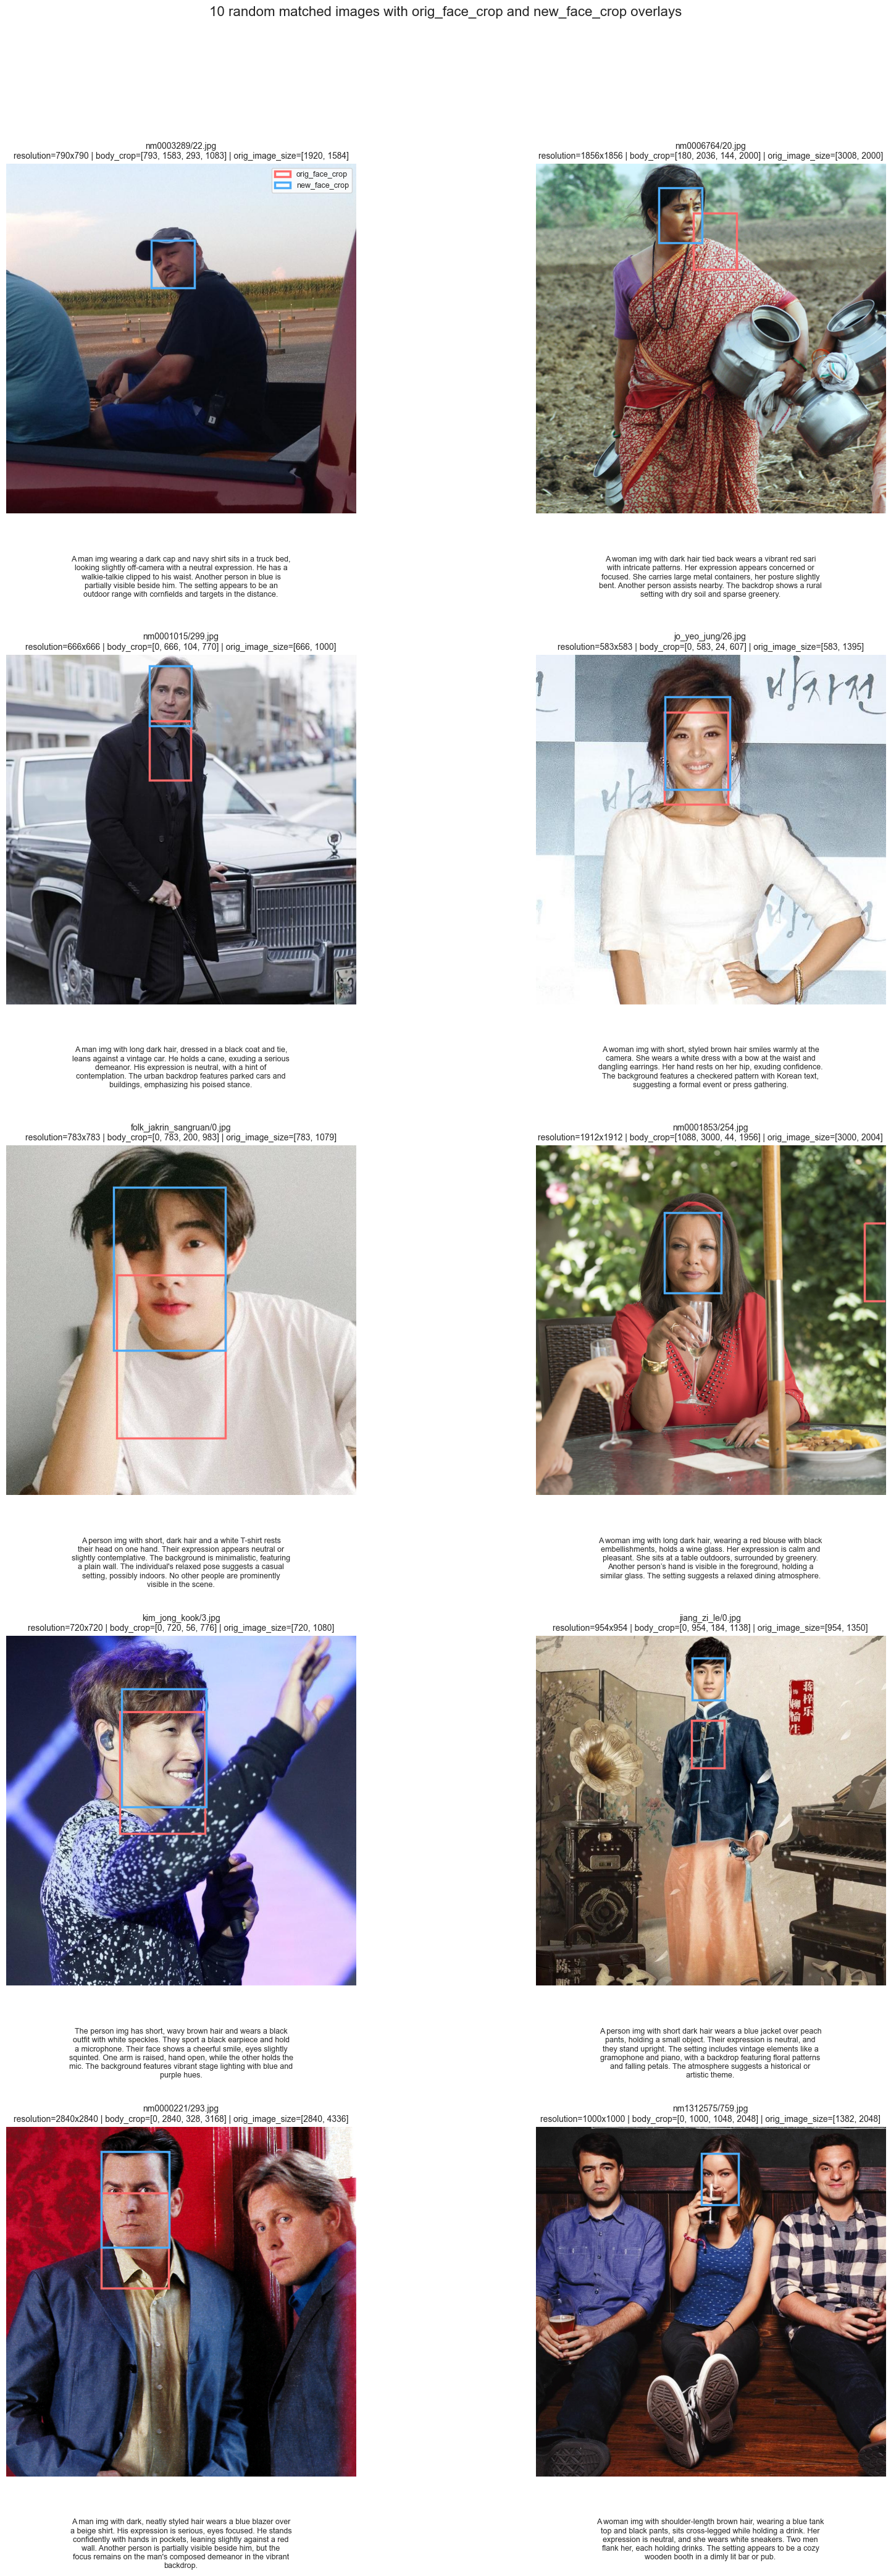

,folder,image_id,body_crop,orig_image_size,text
0,nm0003289,22,"[793, 1583, 293, 1083]","[1920, 1584]",A man img wearing a dark cap and navy shirt si...
1,nm0006764,20,"[180, 2036, 144, 2000]","[3008, 2000]",A woman img with dark hair tied back wears a v...
2,nm0001015,299,"[0, 666, 104, 770]","[666, 1000]","A man img with long dark hair, dressed in a bl..."
3,jo_yeo_jung,26,"[0, 583, 24, 607]","[583, 1395]","A woman img with short, styled brown hair smil..."
4,folk_jakrin_sangruan,0,"[0, 783, 200, 983]","[783, 1079]","A person img with short, dark hair and a white..."
5,nm0001853,254,"[1088, 3000, 44, 1956]","[3000, 2004]","A woman img with long dark hair, wearing a red..."
6,kim_jong_kook,3,"[0, 720, 56, 776]","[720, 1080]","The person img has short, wavy brown hair and ..."
7,jiang_zi_le,0,"[0, 954, 184, 1138]","[954, 1350]",A person img with short dark hair wears a blue...
8,nm0000221,293,"[0, 2840, 328, 3168]","[2840, 4336]","A man img with dark, neatly styled hair wears ..."
9,nm1312575,759,"[0, 1000, 1048, 2048]","[1382, 2048]","A woman img with shoulder-length brown hair, w..."


In [4]:
def add_crop_box(ax, crop, color, label):
    x0, y0, x1, y1 = crop
    rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color, linewidth=2.5, label=label)
    ax.add_patch(rect)


sample_df = analysis_df.head(0).copy()

if analysis_df.empty:
    print("No matched image/metadata pairs are available for manual inspection.")
else:
    sample_df = analysis_df.sample(n=min(SAMPLE_SIZE, len(analysis_df)), random_state=RNG_SEED).reset_index(drop=True)

    cols = 2
    rows = int(np.ceil(len(sample_df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 8.5))
    axes = np.atleast_1d(axes).ravel()

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    for idx, (ax, row) in enumerate(zip(axes, sample_df.itertuples(index=False))):
        with Image.open(row.image_path) as image_file:
            image = image_file.convert("RGB")
        width, height = image.size

        ax.imshow(image)
        add_crop_box(ax, row.orig_face_crop, "#ff6b6b", "orig_face_crop")
        add_crop_box(ax, row.new_face_crop, "#4dabf7", "new_face_crop")
        ax.set_title(
            f"{row.folder}/{row.image_id}{row.image_path.suffix}\n"
            f"resolution={width}x{height} | body_crop={row.body_crop} | orig_image_size={row.orig_image_size}",
            fontsize=10,
        )
        ax.text(
            0.5,
            -0.12,
            textwrap.fill(str(row.text), width=65),
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=9,
            wrap=True,
        )
        if idx == 0:
            ax.legend(loc="upper right", fontsize=9, frameon=True)
        ax.axis("off")

    fig.suptitle("10 random matched images with orig_face_crop and new_face_crop overlays", fontsize=16, y=1.02)
    fig.tight_layout(rect=(0, 0.04, 1, 0.98), h_pad=3.0)
    plt.show()

    display(sample_df[["folder", "image_id", "body_crop", "orig_image_size", "text"]])


,metric,value
0,Images with matched JSON data,127283.000000
1,Images with body_crop_width > 1024,81650.000000
2,Images with new_face_crop_width > 200,74101.000000
3,Average images per class for new_face_crop_wid...,19.408329
4,Images with new_face_crop_width > 350,35133.000000
5,Average images per class for new_face_crop_wid...,10.382092


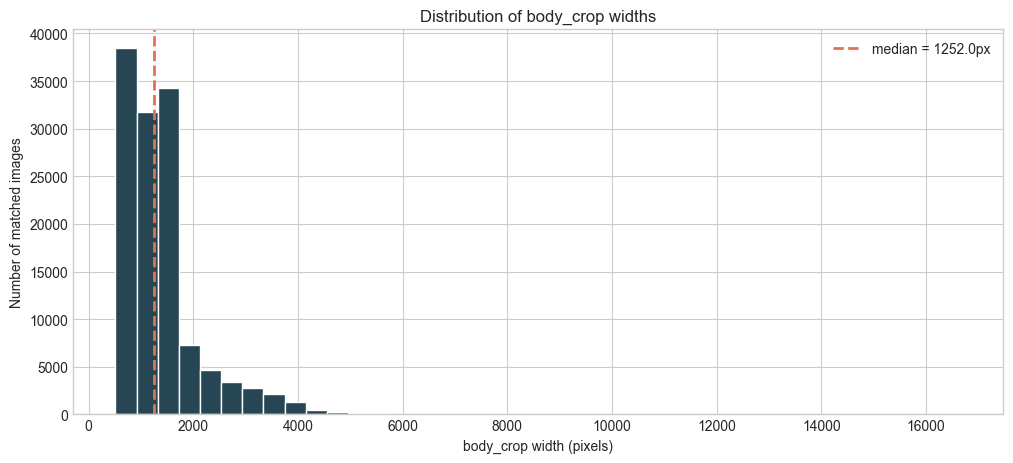

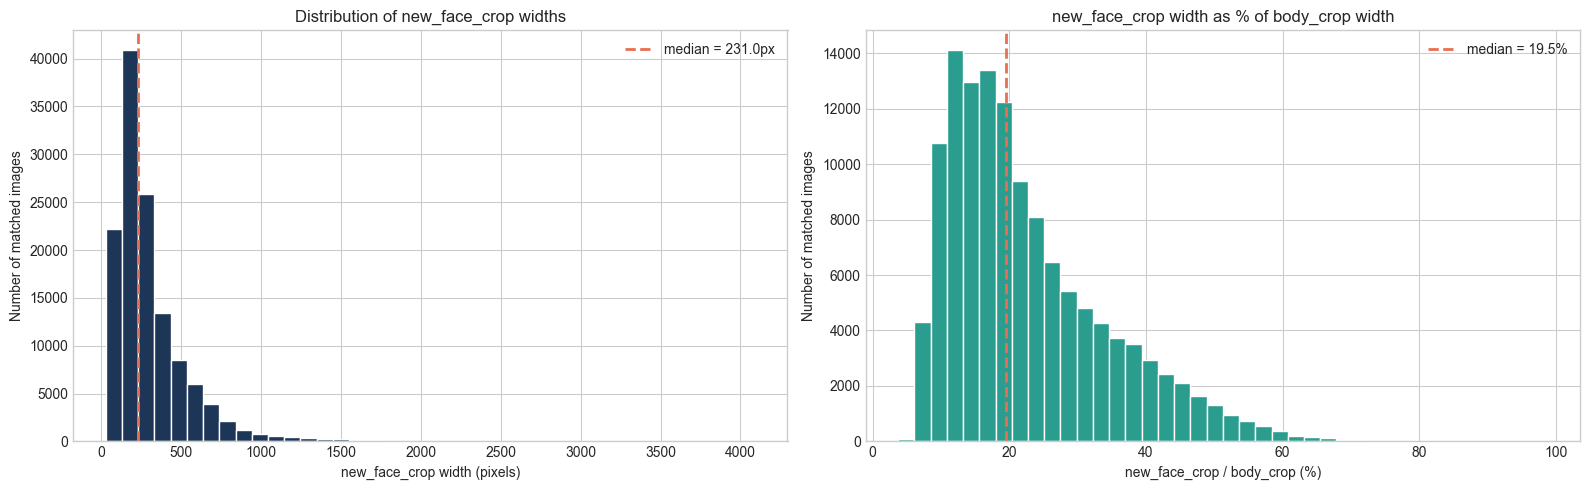

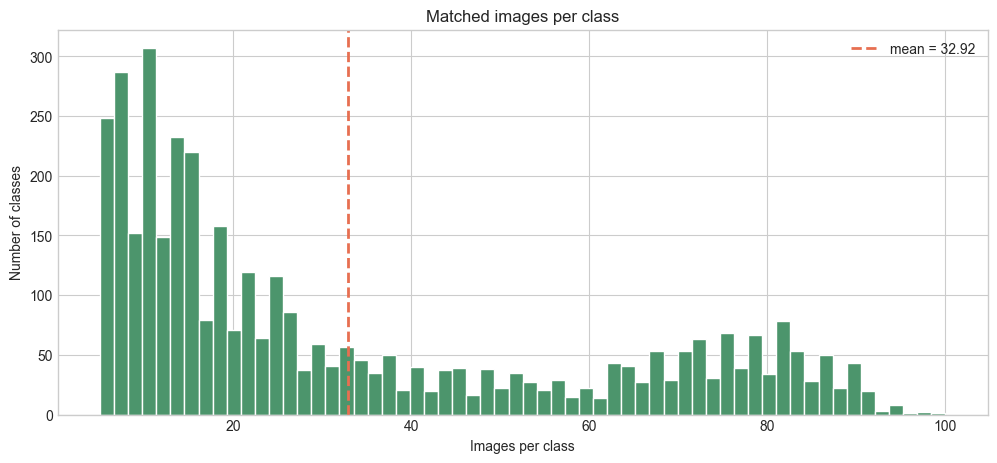

Images with new_face_crop_width > 200: 74,101
Average images per class for new_face_crop_width > 200: 19.41
Classes represented for new_face_crop_width > 200: 3,818


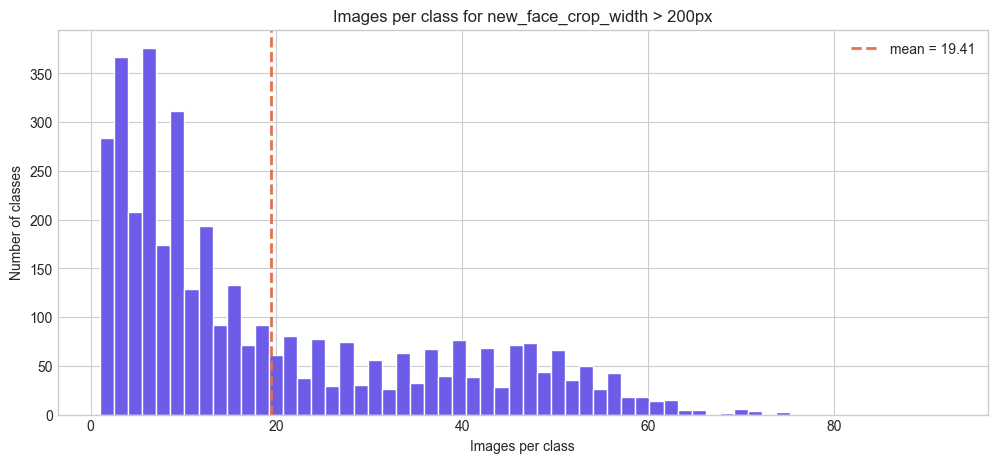

Images with new_face_crop_width > 350: 35,133
Average images per class for new_face_crop_width > 350: 10.38
Classes represented for new_face_crop_width > 350: 3,384


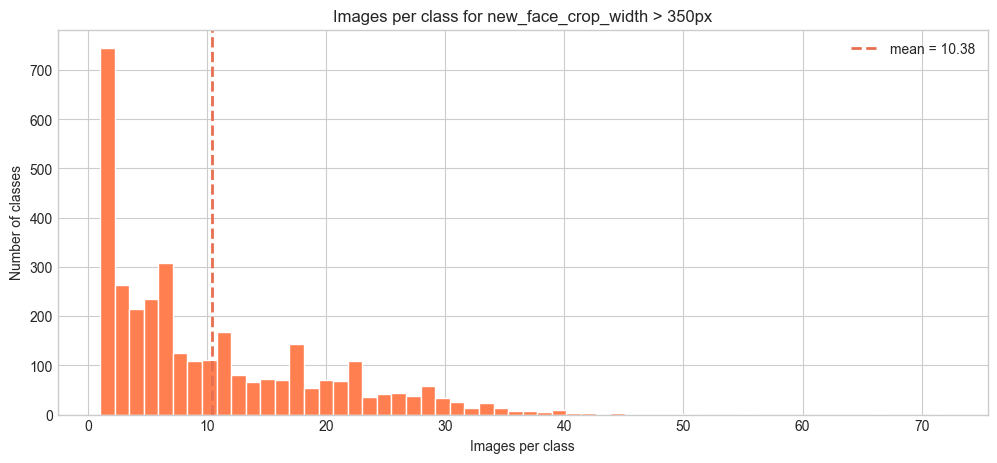

,count,mean,std,min,25%,50%,75%,max
body_crop_width,127283.0,1356.405687,784.940452,512.000000,800.000000,1252.000000,1480.000000,16667.000000
new_face_crop_width,127283.0,303.055765,246.088788,26.000000,149.000000,231.000000,374.000000,4091.000000
new_face_pct_of_body,127283.0,22.697331,11.827191,3.719008,13.699132,19.481481,29.065063,98.765432
matched_images_per_class,3866.0,32.923694,26.782940,5.000000,11.000000,21.000000,54.000000,100.000000


,count,mean,std,min,25%,50%,75%,max
new_face_gt_200_per_class,3818.0,19.408329,17.188718,1.0,6.0,12.0,31.0,92.0


,count,mean,std,min,25%,50%,75%,max
new_face_gt_350_per_class,3384.0,10.382092,9.422129,1.0,3.0,7.0,16.0,72.0


In [5]:
if analysis_df.empty:
    print("No matched image/metadata pairs are available for plotting.")
else:
    face_gt_200_df, face_gt_200_per_class, face_gt_200_avg = get_face_threshold_subset(analysis_df, 200)
    face_gt_350_df, face_gt_350_per_class, face_gt_350_avg = get_face_threshold_subset(analysis_df, 350)

    threshold_summary_df = pd.DataFrame(
        [
            {"metric": "Images with matched JSON data", "value": int(len(analysis_df))},
            {"metric": "Images with body_crop_width > 1024", "value": int(analysis_df["body_crop_width"].gt(1024).sum())},
            {"metric": "Images with new_face_crop_width > 200", "value": int(len(face_gt_200_df))},
            {"metric": "Average images per class for new_face_crop_width > 200", "value": face_gt_200_avg},
            {"metric": "Images with new_face_crop_width > 350", "value": int(len(face_gt_350_df))},
            {"metric": "Average images per class for new_face_crop_width > 350", "value": face_gt_350_avg},
        ]
    )
    display(threshold_summary_df)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(analysis_df["body_crop_width"].dropna(), bins=40, color="#264653", edgecolor="white")
    median_body = analysis_df["body_crop_width"].median()
    ax.axvline(median_body, color="#e76f51", linestyle="--", linewidth=2, label=f"median = {median_body:.1f}px")
    ax.set_title("Distribution of body_crop widths")
    ax.set_xlabel("body_crop width (pixels)")
    ax.set_ylabel("Number of matched images")
    ax.legend()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(analysis_df["new_face_crop_width"].dropna(), bins=40, color="#1d3557", edgecolor="white")
    median_face = analysis_df["new_face_crop_width"].median()
    axes[0].axvline(median_face, color="#e76f51", linestyle="--", linewidth=2, label=f"median = {median_face:.1f}px")
    axes[0].set_title("Distribution of new_face_crop widths")
    axes[0].set_xlabel("new_face_crop width (pixels)")
    axes[0].set_ylabel("Number of matched images")
    axes[0].legend()

    axes[1].hist(analysis_df["new_face_pct_of_body"].dropna(), bins=40, color="#2a9d8f", edgecolor="white")
    median_ratio = analysis_df["new_face_pct_of_body"].median()
    axes[1].axvline(median_ratio, color="#e76f51", linestyle="--", linewidth=2, label=f"median = {median_ratio:.1f}%")
    axes[1].set_title("new_face_crop width as % of body_crop width")
    axes[1].set_xlabel("new_face_crop / body_crop (%)")
    axes[1].set_ylabel("Number of matched images")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    plot_images_per_class_hist(
        matched_images_per_class,
        title="Matched images per class",
        color="#4c956c",
    )

    print(f"Images with new_face_crop_width > 200: {len(face_gt_200_df):,}")
    print(f"Average images per class for new_face_crop_width > 200: {face_gt_200_avg:.2f}")
    print(f"Classes represented for new_face_crop_width > 200: {len(face_gt_200_per_class):,}")
    plot_images_per_class_hist(
        face_gt_200_per_class,
        title="Images per class for new_face_crop_width > 200px",
        color="#6c5ce7",
    )

    print(f"Images with new_face_crop_width > 350: {len(face_gt_350_df):,}")
    print(f"Average images per class for new_face_crop_width > 350: {face_gt_350_avg:.2f}")
    print(f"Classes represented for new_face_crop_width > 350: {len(face_gt_350_per_class):,}")
    plot_images_per_class_hist(
        face_gt_350_per_class,
        title="Images per class for new_face_crop_width > 350px",
        color="#ff7f50",
    )

    summary_stats_df = pd.concat(
        [
            analysis_df[["body_crop_width", "new_face_crop_width", "new_face_pct_of_body"]].describe().T,
            matched_images_per_class.describe().to_frame(name="matched_images_per_class").T,
        ]
    )
    display(summary_stats_df)

    if not face_gt_200_per_class.empty:
        display(face_gt_200_per_class.describe().to_frame(name="new_face_gt_200_per_class").T)
    if not face_gt_350_per_class.empty:
        display(face_gt_350_per_class.describe().to_frame(name="new_face_gt_350_per_class").T)


In [7]:
from pathlib import Path
import json
import pandas as pd

OUTPUT_JSON = Path("large_dataset_filtered_body1024_face200_min5_top30.json")

BODY_CROP_MIN = 1024
FACE_CROP_MIN = 200
MIN_IMAGES_PER_CLASS = 5
MAX_IMAGES_PER_CLASS = 30

# 1) Filter image-level conditions on matched data only
selected_df = analysis_df.loc[
    (analysis_df["body_crop_width"] > BODY_CROP_MIN)
    & (analysis_df["new_face_crop_width"] > FACE_CROP_MIN)
].copy()

# 2) Keep only classes with at least 5 qualifying images
qualifying_counts_before_cap = selected_df.groupby("folder").size()
eligible_classes = qualifying_counts_before_cap[qualifying_counts_before_cap >= MIN_IMAGES_PER_CLASS].index
selected_df = selected_df[selected_df["folder"].isin(eligible_classes)].copy()

# 3) If a class has more than 30 images, keep top 30 by highest new_face_crop_width
selected_df = (
    selected_df.sort_values(
        by=["folder", "new_face_crop_width", "body_crop_width", "image_id"],
        ascending=[True, False, False, True],
    )
    .groupby("folder", group_keys=False)
    .head(MAX_IMAGES_PER_CLASS)
    .reset_index(drop=True)
)

# 4) Derived field for stats: new_face_crop as % of body_crop
selected_df["new_face_crop_as_pct_of_body_crop"] = (
    selected_df["new_face_crop_width"] / selected_df["body_crop_width"] * 100.0
)

# 5) Build JSON payload with paths relative to dataset_full/
payload = {
    "selection_criteria": {
        "body_crop_width_gt": BODY_CROP_MIN,
        "new_face_crop_width_gt": FACE_CROP_MIN,
        "min_images_per_class": MIN_IMAGES_PER_CLASS,
        "max_images_per_class": MAX_IMAGES_PER_CLASS,
        "note": "Paths are relative to dataset_full/",
    },
    "summary": {
        "num_images": int(len(selected_df)),
        "num_classes": int(selected_df["folder"].nunique()),
    },
    "classes": {},
}

for folder, group in selected_df.groupby("folder", sort=True):
    group = group.copy()
    group["image_path_rel"] = group["image_path"].map(lambda p: Path(p).as_posix())

    payload["classes"][folder] = {
        "folder_path": f"large_dataset/{folder}",
        "num_images": int(len(group)),
        "images": [
            {
                "image_id": row.image_id,
                "image_path": row.image_path_rel,
                "body_crop_width": int(row.body_crop_width),
                "new_face_crop_width": int(row.new_face_crop_width),
                "new_face_crop_as_pct_of_body_crop": round(float(row.new_face_crop_as_pct_of_body_crop), 4),
            }
            for row in group.itertuples(index=False)
        ],
    }

OUTPUT_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Saved JSON to: {OUTPUT_JSON.resolve()}")

# 6) Summary stats
if selected_df.empty:
    print("No images matched the selection criteria.")
else:
    images_per_class = selected_df.groupby("folder").size().rename("images_per_class")

    summary_stats_df = pd.DataFrame(
        {
            "min": [
                float(images_per_class.min()),
                float(selected_df["body_crop_width"].min()),
                float(selected_df["new_face_crop_width"].min()),
                float(selected_df["new_face_crop_as_pct_of_body_crop"].min()),
            ],
            "mean": [
                float(images_per_class.mean()),
                float(selected_df["body_crop_width"].mean()),
                float(selected_df["new_face_crop_width"].mean()),
                float(selected_df["new_face_crop_as_pct_of_body_crop"].mean()),
            ],
            "median": [
                float(images_per_class.median()),
                float(selected_df["body_crop_width"].median()),
                float(selected_df["new_face_crop_width"].median()),
                float(selected_df["new_face_crop_as_pct_of_body_crop"].median()),
            ],
            "max": [
                float(images_per_class.max()),
                float(selected_df["body_crop_width"].max()),
                float(selected_df["new_face_crop_width"].max()),
                float(selected_df["new_face_crop_as_pct_of_body_crop"].max()),
            ],
        },
        index=[
            "images_per_class",
            "body_crop_width",
            "new_face_crop_width",
            "new_face_crop_as_pct_of_body_crop",
        ],
    ).round(2)

    print(f"Images found: {len(selected_df):,}")
    print(f"Classes represented: {selected_df['folder'].nunique():,}")
    display(summary_stats_df)


Saved JSON to: /home/kolyangg/rsrch/dataset_full/large_dataset_filtered_body1024_face200_min5_top30.json
Images found: 47,502
Classes represented: 2,561


,min,mean,median,max
images_per_class,5.00,18.55,18.00,30.00
body_crop_width,1025.00,1925.96,1506.00,16667.00
new_face_crop_width,201.00,502.08,427.00,4091.00
new_face_crop_as_pct_of_body_crop,5.97,27.51,24.89,93.91
